## ARIMAX

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import pickle

In [2]:
# Load merged data: prioritize CSV 'merged_data_final.csv', fallback to pickle or synthetic data for testing
import os
csv_path = '../data/processed/merged_data_final.csv'
data = pd.read_csv(csv_path, parse_dates=['datetime'])

# Ensure datetime is set as the time index
if 'datetime' in data.columns:
    data['datetime'] = pd.to_datetime(data['datetime'])
    data.set_index('datetime', inplace=True)

# Use 'close' as the target series
close_prices = data['close']

# Prepare exogenous variables. If missing, print warning and fill with 0 to ensure dimension consistency
exog_cols = ['roe_lag45d','ps_lag45d','de_ratio_lag45d','CAPEI_lag45d','bm_lag45d']
missing = [c for c in exog_cols if c not in data.columns]
if missing:
    print(f'Warning: The following exogenous variable columns are missing in the data and will be filled with 0: {missing}')
    for c in missing:
        data[c] = 0.0

# Construct exog DataFrame, ensuring correct order and alignment with close_prices
exog = data[exog_cols].astype(float)
# Simple check: length should match
assert len(exog) == len(close_prices), 'Exogenous variable length does not match target series length'

In [12]:
# Automatically select ARIMAX (with exogenous variables) parameters: use exog as the exogenous variable
# Note: the exogenous parameter name in auto_arima is 'exogenous'
model = auto_arima(close_prices, exogenous=exog, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=18647.598, Time=11.27 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=18715.539, Time=5.84 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=18658.496, Time=3.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=18658.534, Time=2.50 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=18715.733, Time=3.23 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=18656.071, Time=9.55 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=18662.495, Time=8.46 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=18651.751, Time=30.02 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=18648.050, Time=47.65 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=18660.481, Time=3.71 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=18648.455, Time=13.41 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=18655.612, Time=12.91 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=18649.770, Time=34.49 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=18647.445, Time=8.96 sec
 ARIMA(1,1,2)


==================== Close Price Stationarity Test Report ====================
ADF Statistic: -1.6411
p-value:       0.4617
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Conclusion: p-value >= 0.05, the data is [NON-STATIONARY] (trend or unit root exists).


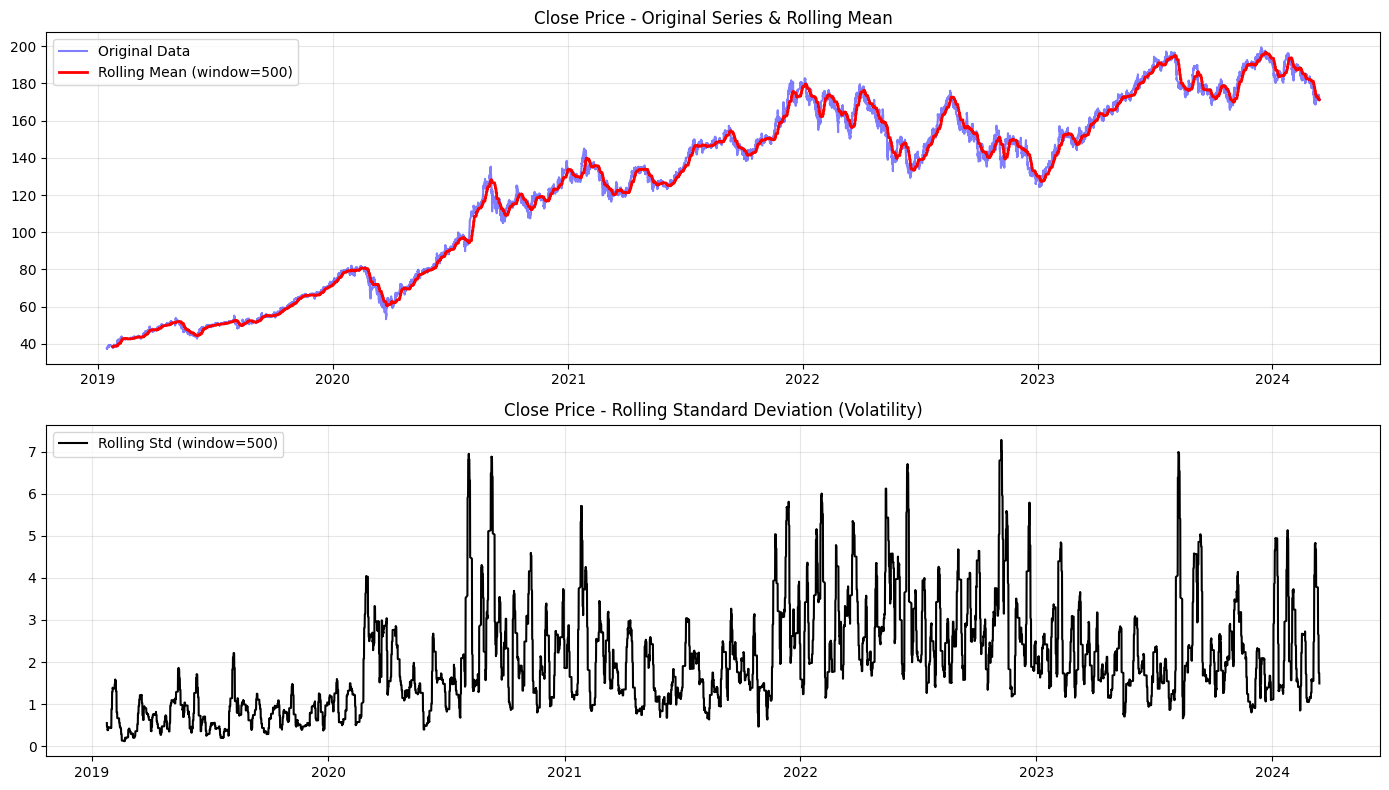


Original data detected as non-stationary, testing 1st Order Differenced data...

==================== 1st Order Differenced Close Price Stationarity Test Report ====================
ADF Statistic: -91.5038
p-value:       0.0000
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Conclusion: p-value < 0.05, the data is [STATIONARY].


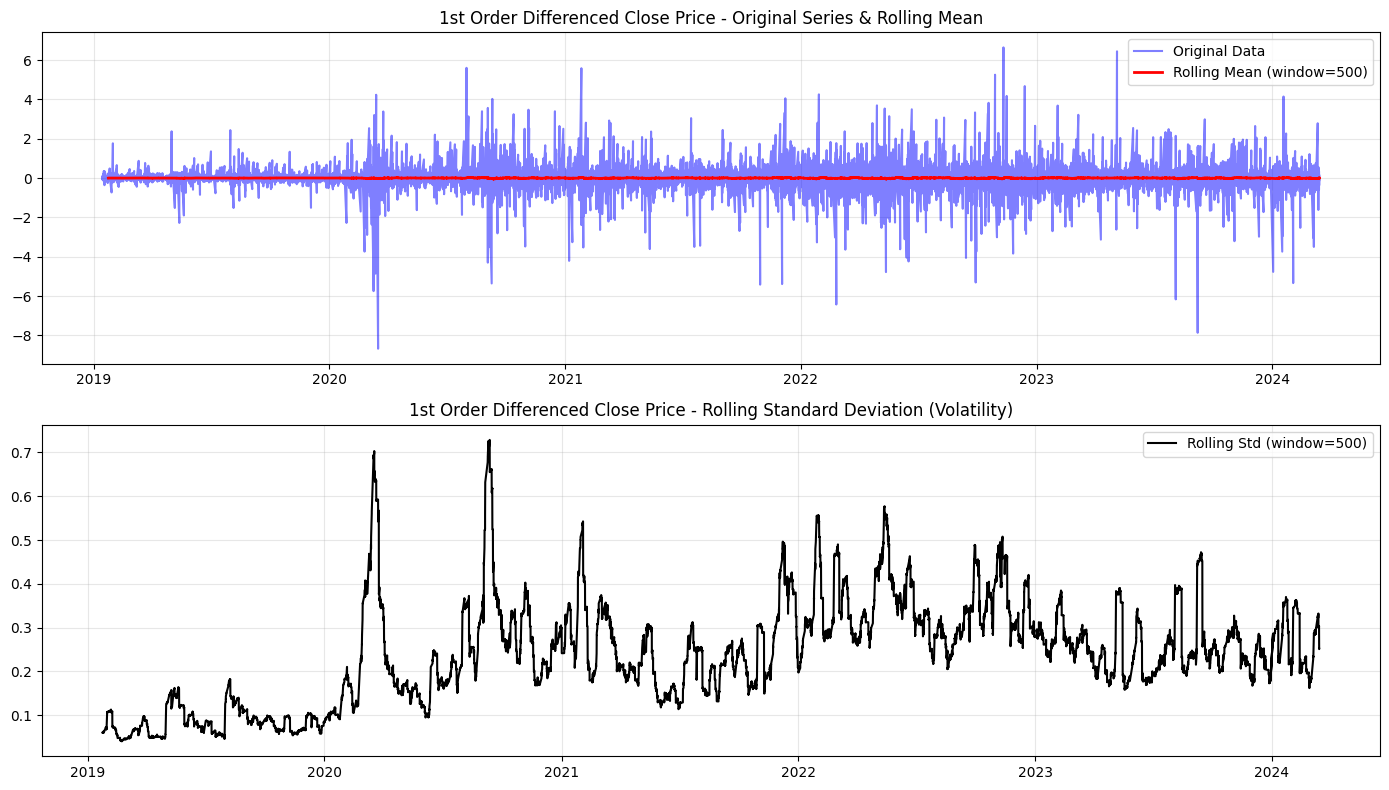


==================== Exogenous Variables Stationarity Overview ====================
Variable             | p-value    | Stationary?
---------------------------------------------
roe_lag45d           | 0.9038     | No
ps_lag45d            | 0.4260     | No
de_ratio_lag45d      | 0.6708     | No
CAPEI_lag45d         | 0.4149     | No
bm_lag45d            | 0.6805     | No


In [19]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity_and_plot(series, title="Time Series", window_size=1000):
    """
    Performs the Augmented Dickey-Fuller (ADF) test and plots the stationarity analysis (Original Data vs Rolling Mean/Std Dev)
    """
    print(f"\n{'='*20} {title} Stationarity Test Report {'='*20}")
    
    # 1. ADF Statistical Test
    # Note: ADF cannot handle NaN, they must be removed
    clean_series = series.dropna()
    result = adfuller(clean_series)
    
    p_value = result[1]
    is_stationary = p_value < 0.05
    
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    if is_stationary:
        print(f"Conclusion: p-value < 0.05, the data is [STATIONARY].")
    else:
        print(f"Conclusion: p-value >= 0.05, the data is [NON-STATIONARY] (trend or unit root exists).")

    # 2. Plotting Analysis
    plt.figure(figsize=(14, 8))
    
    # Top plot: Original data + Rolling Mean
    plt.subplot(2, 1, 1)
    plt.plot(series, label='Original Data', color='blue', alpha=0.5)
    # Calculate Rolling Mean and Rolling Standard Deviation
    rolmean = series.rolling(window=window_size).mean()
    rolstd = series.rolling(window=window_size).std()
    
    plt.plot(rolmean, label=f'Rolling Mean (window={window_size})', color='red', linewidth=2)
    plt.legend(loc='best')
    plt.title(f'{title} - Original Series & Rolling Mean')
    plt.grid(True, alpha=0.3)
    
    # Bottom plot: Rolling Standard Deviation (to check if volatility is stable)
    plt.subplot(2, 1, 2)
    plt.plot(rolstd, label=f'Rolling Std (window={window_size})', color='black')
    plt.legend(loc='best')
    plt.title(f'{title} - Rolling Standard Deviation (Volatility)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return is_stationary

# ==========================================
# Execution Code
# ==========================================

# 1. Test the Target Variable (Close Price)
# Original prices are typically non-stationary
is_close_stationary = check_stationarity_and_plot(close_prices, "Close Price", window_size=500)

# 2. If non-stationary, test the First Difference data
# This is what d=1 does in auto_arima
if not is_close_stationary:
    print("\nOriginal data detected as non-stationary, testing 1st Order Differenced data...")
    diff_series = close_prices.diff()
    check_stationarity_and_plot(diff_series, "1st Order Differenced Close Price", window_size=500)

# 3. (Optional) Quick check for Exogenous Variables
# ARIMAX preferably requires exogenous variables to be stationary. Print only text results to avoid excessive plots.
print(f"\n{'='*20} Exogenous Variables Stationarity Overview {'='*20}")
print(f"{'Variable':<20} | {'p-value':<10} | {'Stationary?'}")
print("-" * 45)

for col in exog_cols:
    clean_exog = data[col].dropna()
    res = adfuller(clean_exog)
    p_val = res[1]
    status = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<20} | {p_val:.4f}     | {status}")

In [20]:
# Fit the ARIMAX model using the selected parameters (including exogenous variables exog)
order = model.order
# Pass exog into the model to construct ARIMAX
arima_model = ARIMA(close_prices, order=order, exog=exog)
arima_result = arima_model.fit()
print(arima_result.summary())

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('N

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               101860
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -9912.850
Date:                Thu, 20 Nov 2025   AIC                          19845.700
Time:                        07:29:35   BIC                          19941.013
Sample:                             0   HQIC                         19874.601
                             - 101860                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
roe_lag45d         -3.9035      0.181    -21.565      0.000      -4.258      -3.549
ps_lag45d          -0.7071      0.040    -17.706      0.000      -0.785      -0.629
de_ratio_lag45d     1.2180      

In [21]:
# Forecast future values (e.g., for the next 100 periods), with simple handling for exogenous variables: repeat the most recently observed exog values
forecast_steps = 100
# Create a time index for the future forecast (assuming 5-minute data interval)
last_datetime = close_prices.index[-1]
forecast_index = pd.date_range(start=last_datetime, periods=forecast_steps+1, freq='5min')[1:]  # Assuming 5-minute data

# Construct future exogenous variables: here we make a simple assumption—repeat the last observed exog value for 'forecast_steps' times
# A more robust approach would be to build separate forecasts for each exogenous variable, but that is outside the current modification scope
future_exog = pd.DataFrame([exog.iloc[-1].values] * forecast_steps, columns=exog.columns, index=forecast_index)

# Use arima_result.forecast by passing the future exog (for ARIMAX)
forecast = arima_result.forecast(steps=forecast_steps, exog=future_exog)

# For predictions on the test set (to compare with actual values), a corresponding exog slice must be provided
test_size = len(close_prices) - int(len(close_prices) * 0.8)
start_idx = len(close_prices) - test_size
end_idx = len(close_prices) - 1
exog_test_slice = exog.iloc[start_idx: end_idx + 1]
arima_test_forecast = arima_result.predict(start=start_idx, end=end_idx, exog=exog_test_slice)

# Combine actual values and forecasts for plotting
actual_series = close_prices
forecast_series = pd.Series(forecast.values, index=forecast_index)
arima_test_series = pd.Series(arima_test_forecast, index=close_prices.index[-test_size:])

c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\anaconda3\envs\MLE\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [22]:
# ============================
# Evaluation Metrics (MSE, MAE, RMSE)
# ============================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Extract true test values and predicted test values
y_true = actual_series.iloc[start_idx: end_idx + 1]
y_pred = arima_test_series

# Ensure alignment (important for time series)
y_true, y_pred = y_true.align(y_pred, join='inner')

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("\n==== Model Evaluation Metrics (Test Set) ====")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


==== Model Evaluation Metrics (Test Set) ====
MSE : 0.0672
MAE : 0.1523
RMSE: 0.2592


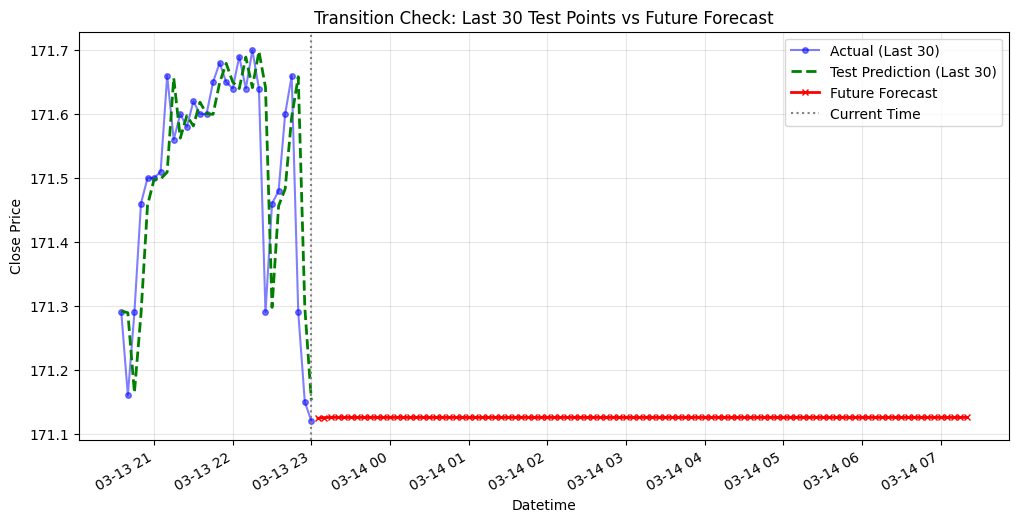

In [23]:
# Set the size of the focused window
window_size = 30

plt.figure(figsize=(12, 6))

# 1. Plot the last 30 actual values (as the baseline reference)
# Use .tail(window_size) to automatically get the last 30 points
plt.plot(close_prices.index[-window_size:], 
         close_prices.tail(window_size), 
         label='Actual (Last 30)', color='blue', marker='o', markersize=4, alpha=0.5)

# 2. Plot the last 30 test set predictions (to see model performance at the end of known data)
# Assuming arima_test_series is long enough, take the last 30 points
if len(arima_test_series) >= window_size:
    plt.plot(arima_test_series.index[-window_size:], 
             arima_test_series.tail(window_size), 
             label='Test Prediction (Last 30)', color='green', linestyle='--', linewidth=2)

# 3. Plot the future forecast (all points)
plt.plot(forecast_series.index, 
         forecast_series, 
         label='Future Forecast', color='red', marker='x', markersize=4, linewidth=2)

# Add a vertical line to mark the 'current time' boundary
last_date = close_prices.index[-1]
plt.axvline(x=last_date, color='gray', linestyle=':', label='Current Time')

plt.title(f'Transition Check: Last {window_size} Test Points vs Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Automatically rotate date labels to prevent overlap
plt.gcf().autofmt_xdate()

plt.show()

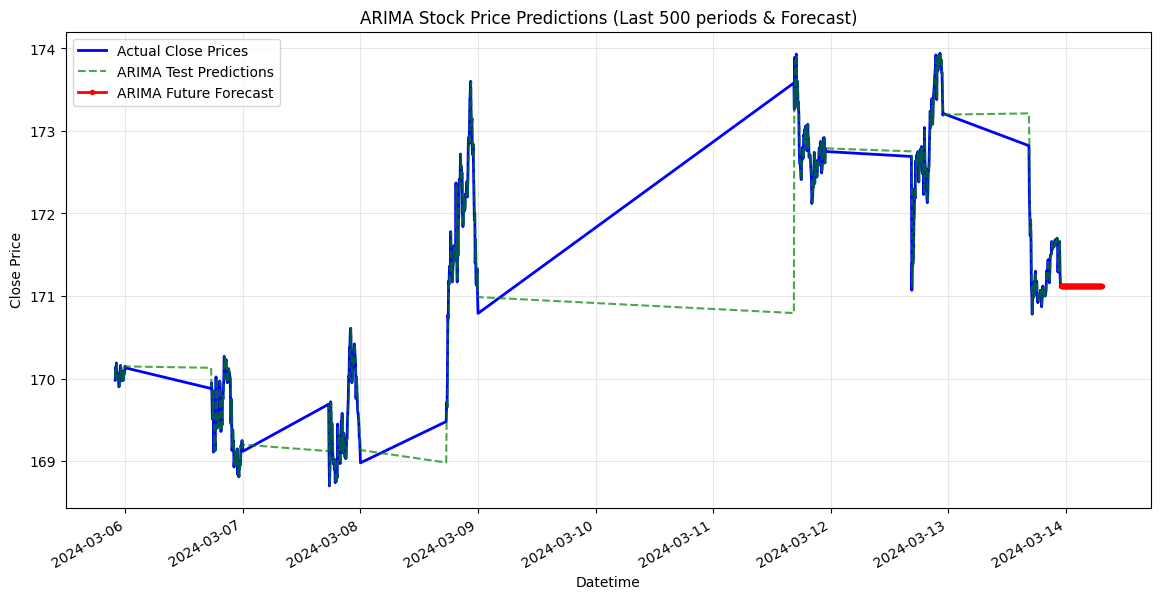

In [24]:
# Set the display window size (e.g., only show the last 500 points + future forecast)
zoom_window = 500 

plt.figure(figsize=(14, 7))

# 1. Plot historical data (only take the last zoom_window points)
# Use .tail() to slice the end
plt.plot(close_prices.index[-zoom_window:], 
         close_prices.tail(zoom_window), 
         label='Actual Close Prices', color='blue', linewidth=2)

# 2. Plot test set predictions (if there is overlap, only take the most recent)
# Ensure the index is within the zoom_window range before displaying
subset_test = arima_test_series[arima_test_series.index >= close_prices.index[-zoom_window]]
if not subset_test.empty:
    plt.plot(subset_test.index, subset_test, 
             label='ARIMA Test Predictions', color='green', linestyle='--', alpha=0.7)

# 3. Plot future forecast (this is the part you just created, plot all points)
plt.plot(forecast_series.index, forecast_series, 
         label='ARIMA Future Forecast', color='red', marker='.', linestyle='-', linewidth=2)

plt.title(f'ARIMA Stock Price Predictions (Last {zoom_window} periods & Forecast)')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Optimize X-axis time display to prevent overlap
plt.gcf().autofmt_xdate()

plt.show()

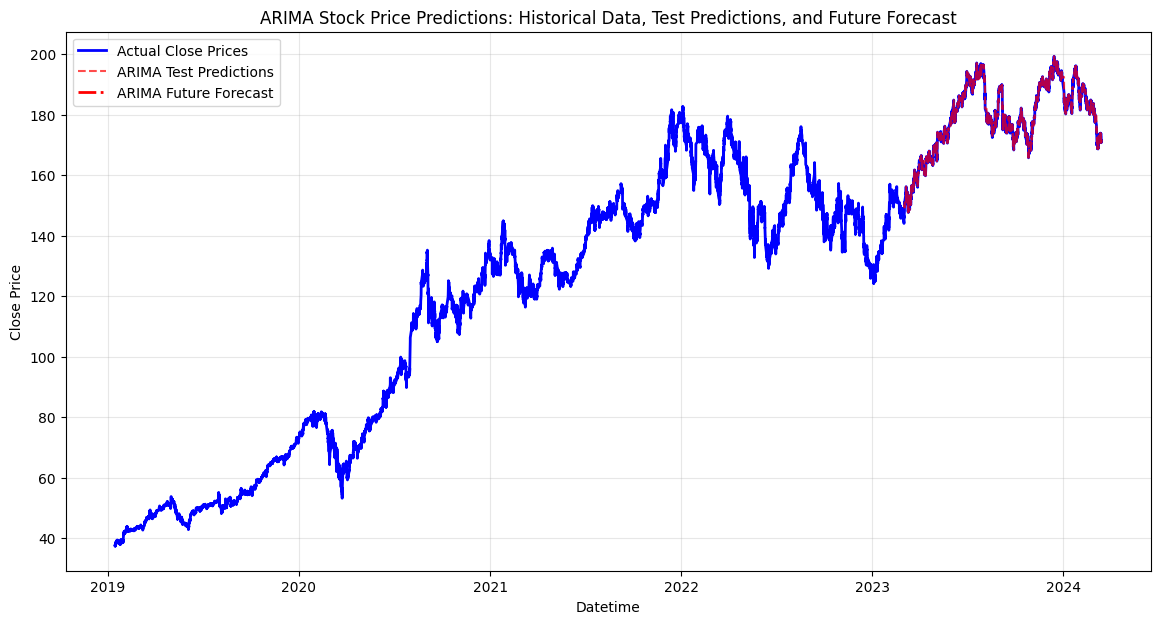

In [25]:
# Plot ARIMA predictions: historical data, test predictions, and future forecast
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(arima_test_series.index, arima_test_series, label='ARIMA Test Predictions', color='red', linestyle='--', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Future Forecast', color='red', linestyle='-.', linewidth=2)
plt.title('ARIMA Stock Price Predictions: Historical Data, Test Predictions, and Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM

In [4]:
# Load the merged data
import pickle
try:
    with open('../data/processed/merged_data.pkl', 'rb') as f:
        data = pickle.load(f)
except Exception as e:
    print(f"Error loading pickle: {e}")
    # Generate sample data for testing
    import numpy as np
    dates = pd.date_range('2023-01-01', periods=1000, freq='5T')
    data = pd.DataFrame({
        'close': np.random.randn(1000).cumsum() + 100,
        'datetime': dates
    })

# Assuming 'close' is the column for stock prices and 'datetime' is the datetime column
# Set datetime as index if not already
if 'datetime' in data.columns:
    data['datetime'] = pd.to_datetime(data['datetime'])
    data.set_index('datetime', inplace=True)

# Use the 'close' column for ARIMA
close_prices = data['close']

In [5]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.train import prepare_lstm_data, train_lstm, predict_lstm
from src.model import LSTMModel



train_loader, test_loader, X_test, scaler, scaled_data, train_size = \
    prepare_lstm_data(close_prices, seq_length=60)

model = LSTMModel()
model = train_lstm(model, train_loader, num_epochs=50)

test_pred, future_pred = predict_lstm(
    model, X_test, scaler, scaled_data, seq_length=60, forecast_steps=100
)

X_batch shape: torch.Size([32, 60, 1])
y_batch shape: torch.Size([32, 1])
outputs shape: torch.Size([32, 1])
sample y: [0.007077917456626892, 0.8454450964927673, 0.7983402609825134, 0.7353712916374207, 0.6642869710922241]
sample outputs: [-0.16469132900238037, -0.15127265453338623, -0.15196844935417175, -0.1529114544391632, -0.15404768288135529]
Epoch [10/50], Loss (last batch): 0.00000053, Loss (avg): 0.00000645
Epoch [20/50], Loss (last batch): 0.00000250, Loss (avg): 0.00000504
Epoch [30/50], Loss (last batch): 0.00000047, Loss (avg): 0.00000447
Epoch [40/50], Loss (last batch): 0.00000106, Loss (avg): 0.00000410
Epoch [50/50], Loss (last batch): 0.00000125, Loss (avg): 0.00000403
Training completed.


In [ ]:
# Import PyTorch libraries for LSTM
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [7]:
# Prepare data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices.values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 60  # Use 60 time steps (5 hours of 5-min data)
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Prepare data for LSTM
raw_train_size = int(len(close_prices) * 0.8)
train_data_raw = close_prices.iloc[:raw_train_size].values.reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(train_data_raw) 

scaled_data = scaler.transform(close_prices.values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 60  # Use 60 time steps (5 hours of 5-min data)
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test
train_split_idx = raw_train_size - seq_length

if train_split_idx < 0:
    raise ValueError("Not enough data to create sequences of the specified length.")

X_train, X_test = X[:train_split_idx], X[train_split_idx:]
y_train, y_test = y[:train_split_idx], y[train_split_idx:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data prepared. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Scaler used: StandardScaler (Mean: {scaler.mean_[0]:.2f}, Scale: {scaler.scale_[0]:.2f})")

Data prepared. Train shape: torch.Size([81428, 60, 1]), Test shape: torch.Size([20372, 60, 1])
Scaler used: StandardScaler (Mean: 112.77, Scale: 42.50)


In [5]:
# Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# Train the LSTM model
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}')
    # if (epoch + 1) % 10 == 0:
    #     print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training completed.")

Epoch [1/50], Loss: 0.00030837
Epoch [2/50], Loss: 0.00015953
Epoch [3/50], Loss: 0.00015509
Epoch [4/50], Loss: 0.00021281
Epoch [5/50], Loss: 0.00002857
Epoch [6/50], Loss: 0.00004129
Epoch [7/50], Loss: 0.00004664
Epoch [8/50], Loss: 0.00002027
Epoch [9/50], Loss: 0.00003017
Epoch [10/50], Loss: 0.00004900
Epoch [11/50], Loss: 0.00031262
Epoch [12/50], Loss: 0.00001503
Epoch [13/50], Loss: 0.00001979
Epoch [14/50], Loss: 0.00002389
Epoch [15/50], Loss: 0.00003384
Epoch [16/50], Loss: 0.00002746
Epoch [17/50], Loss: 0.00004107
Epoch [18/50], Loss: 0.00003386
Epoch [19/50], Loss: 0.00005169
Epoch [20/50], Loss: 0.00007846
Epoch [21/50], Loss: 0.00000980
Epoch [22/50], Loss: 0.00006328
Epoch [23/50], Loss: 0.00001407
Epoch [24/50], Loss: 0.00003349
Epoch [25/50], Loss: 0.00007089
Epoch [26/50], Loss: 0.00007086
Epoch [27/50], Loss: 0.00004878
Epoch [28/50], Loss: 0.00006119
Epoch [29/50], Loss: 0.00003075
Epoch [30/50], Loss: 0.00005398
Epoch [31/50], Loss: 0.00004872
Epoch [32/50], Lo

In [33]:
# Make predictions with LSTM
model.eval()
with torch.no_grad():
    test_predictions = model(X_test).numpy()
    # For forecasting future values, use the last sequence
    last_sequence = scaled_data[-seq_length:].reshape(1, seq_length, 1)
    last_sequence = torch.tensor(last_sequence, dtype=torch.float32)
    future_predictions = []
    for _ in range(forecast_steps):
        pred = model(last_sequence).item()
        future_predictions.append(pred)
        # Update the sequence
        last_sequence = torch.cat((last_sequence[:, 1:, :], torch.tensor([[[pred]]], dtype=torch.float32)), dim=1)

# Inverse transform predictions manually to avoid sklearn-numpy compatibility issues
min_val = scaler.data_min_[0]
scale = scaler.data_max_[0] - scaler.data_min_[0]
test_predictions = test_predictions * scale + min_val
future_predictions = np.array(future_predictions) * scale + min_val

# Create forecast series for LSTM
lstm_forecast_index = pd.date_range(start=close_prices.index[-1], periods=forecast_steps+1, freq='5min')[1:]
lstm_forecast_series = pd.Series(future_predictions, index=lstm_forecast_index)

# Create LSTM test predictions series
lstm_test_index = close_prices.index[seq_length + train_size: seq_length + train_size + len(test_predictions)]
lstm_test_series = pd.Series(test_predictions.flatten(), index=lstm_test_index)

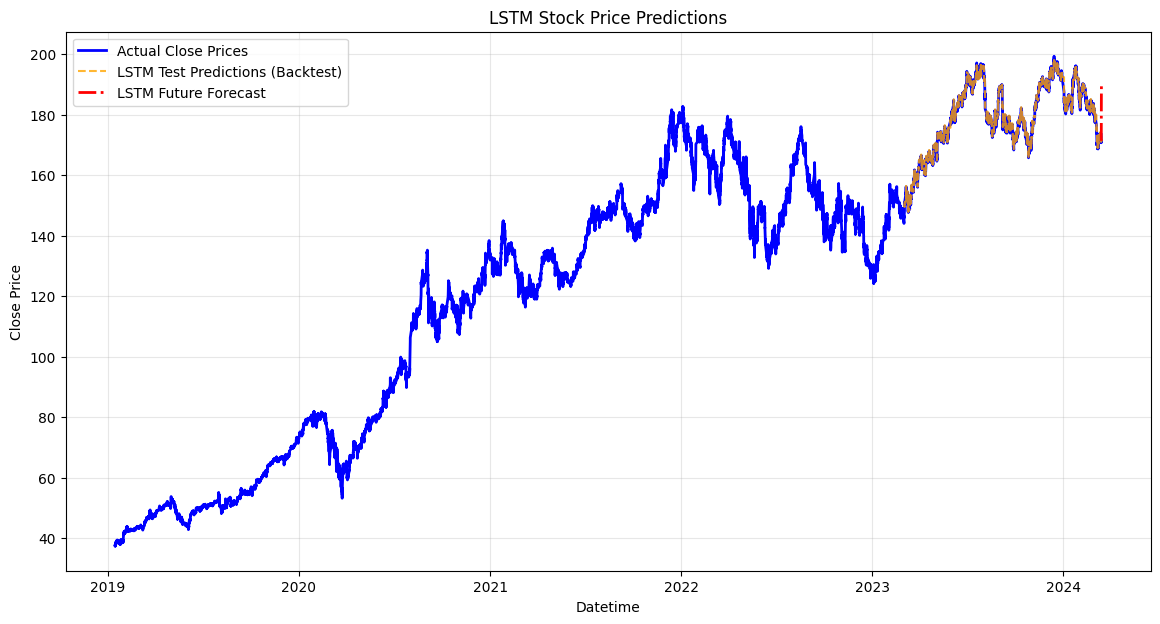

In [ ]:
# Make predictions with LSTM
forecast_steps = 100
model.eval()
with torch.no_grad():
    test_predictions = model(X_test).cpu().numpy()
    # For forecasting future values, use the last sequence
    last_sequence_data = scaled_data[-seq_length:]
    curr_sequence = torch.tensor(last_sequence_data, dtype=torch.float32).unsqueeze(0) # Shape: [1, seq_len, 1]
    
    future_predictions = []
    for _ in range(forecast_steps):
        pred = model(curr_sequence).item()
        future_predictions.append(pred)
        # Update the sequence
        pred_tensor = torch.tensor([[[pred]]], dtype=torch.float32)
        curr_sequence = torch.cat((curr_sequence[:, 1:, :], pred_tensor), dim=1)

test_predictions = scaler.inverse_transform(test_predictions)

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Create forecast series for LSTM
last_timestamp = close_prices.index[-1]
lstm_forecast_index = pd.date_range(start=last_timestamp, periods=forecast_steps+1, freq='5min')[1:]
lstm_forecast_series = pd.Series(future_predictions.flatten(), index=lstm_forecast_index)


lstm_test_index = close_prices.index[raw_train_size : raw_train_size + len(test_predictions)]
lstm_test_series = pd.Series(test_predictions.flatten(), index=lstm_test_index)

In [ ]:
# Plot LSTM predictions
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(lstm_test_series.index, lstm_test_series, label='LSTM Test Predictions (Backtest)', color='orange', linestyle='--', alpha=0.8)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Future Forecast', color='red', linestyle='-.', linewidth=2)

plt.title('LSTM Stock Price Predictions')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

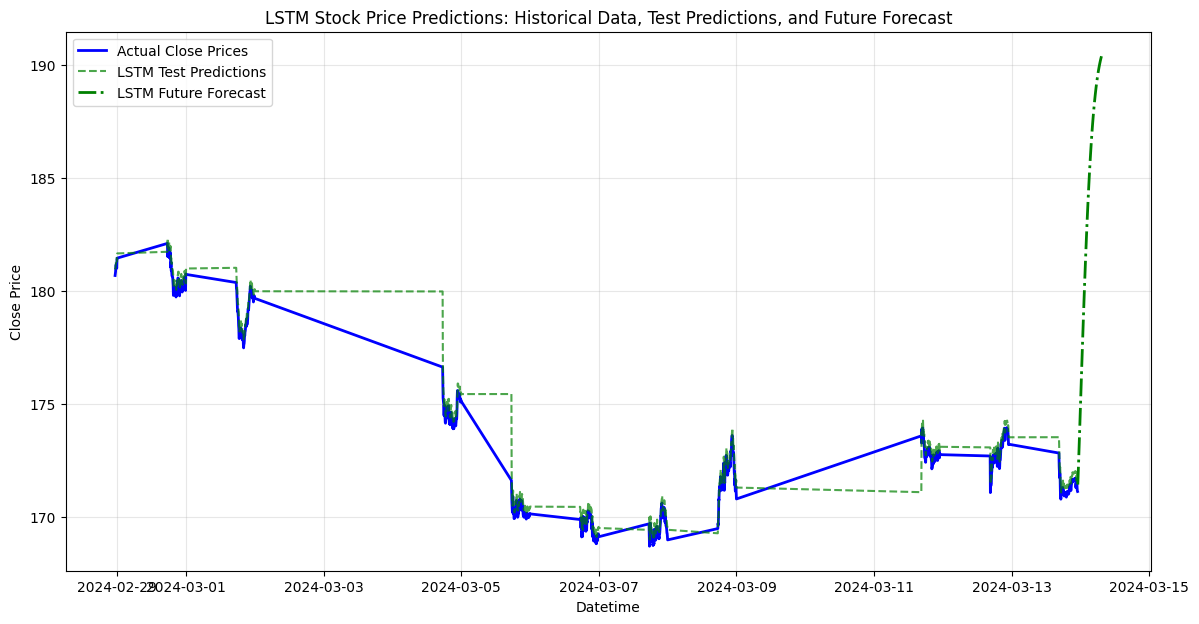

In [19]:
# Plot LSTM predictions: historical data, test predictions, and future forecast
last_n = 800
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index[-last_n:], close_prices.iloc[-last_n:], label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(lstm_test_series.index[-last_n:], lstm_test_series[-last_n:], label='LSTM Test Predictions', color='green', linestyle='--', alpha=0.7)
plt.plot(lstm_forecast_series.index[-last_n:], lstm_forecast_series[-last_n:], label='LSTM Future Forecast', color='green', linestyle='-.', linewidth=2)
plt.title('LSTM Stock Price Predictions: Historical Data, Test Predictions, and Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()